# add_damage_record.ipynb
Add a new damages record to the database.

In [1]:
%matplotlib widget
import ipympl
import matplotlib.pyplot as plt
import sqlite3
from icecream import ic 
import numpy as np
import shapely
from shapely import wkt
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour
import cv2
from shapely.geometry import Polygon
from shapely.wkt import dumps
import re

In [2]:
db_path = 'new.db'
image_id = 1
tree_id = 1
order = 15

In [3]:
# Open a database with images and trees tables populated
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

In [4]:
!jupyter notebook --version

7.5.6


In [5]:
# get WKTs for for trees in a selected image
cursor.execute(f'SELECT AsWKT(tree_poly) FROM trees WHERE image_id={image_id}')
tree_wkts = cursor.fetchall()
# ic(tree_wkts)
# ic(len(tree_wkts))

In [6]:
# Get coordinates array for first tree
wkt_string = tree_wkts[0][0]  # Get the WKT string from the first row
# ic(wkt_string)
# 1. Load the WKT into a Shapely geometry object
polygon = wkt.loads(wkt_string)

# 2. Extract the exterior coordinates and convert to a NumPy array
coords_array = np.array(polygon.exterior.coords)
coords_array = np.abs(coords_array)  # Ensure all coordinates are positive

# ic(coords_array)
# ic(coords_array.shape);

In [7]:
# get elliptic Fourier descriptors for first tree

original_contour = coords_array

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
# ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)
# ic(coeffs)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)
# ic(dc_coeffs)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)
# ic(reconstructed_contour)

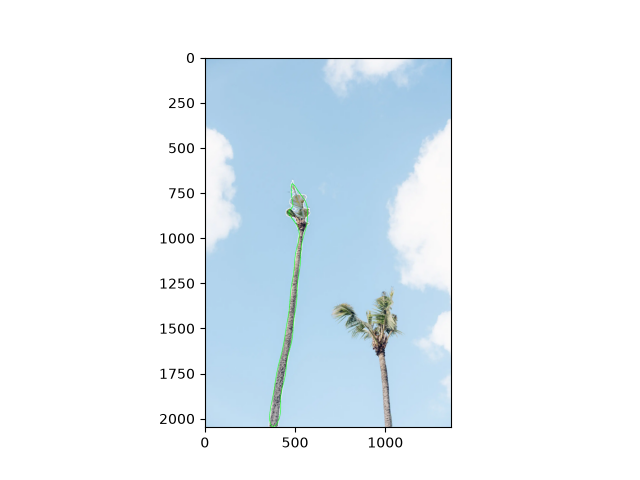

In [8]:
# display image with original contour and reconstructed contour for first tree

cursor.execute(f'SELECT image_path FROM images WHERE image_id = {image_id}')
image_path = cursor.fetchone()
img = cv2.imread(image_path[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# ic(img)

cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
# ic(img)

cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)

# 4. Initialize the figure and axes for the widget window
fig, ax = plt.subplots()

# 5. Render the image inside the interactive widget frame
ax.imshow(img)
plt.show()

In [9]:
# calculate mask containing pixels which are in the reconstruction mask but not in the original mask

original_mask = np.zeros_like(img, dtype=np.uint8)
cv2.fillPoly(original_mask, pts=[original_contour.astype(dtype=np.int32)], color=255)

reconstructed_mask = np.zeros_like(img, dtype=np.uint8)
cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(dtype=np.int32)], color=255)

# Pixels missing in original, present in reconstruction
diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

# remove small blobs using connected components method
#######################################################

# Load your binary image (must be single-channel, uint8)
binary_img = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
ic(binary_img.shape)

# 1. Find all connected components and their statistics
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_img, connectivity=8)

# 2. Define your minimum area threshold (in pixels)
min_area = 200 

# 3. Create an empty mask to store large objects
filtered_img = np.zeros_like(binary_img)

# 4. Loop through components (skip index 0 as it represents the background)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    
    if area >= min_area:
        # Keep components that meet the size constraint
        filtered_img[labels == i] = 255
        

# Find connected components
num_labels, labels_im = cv2.connectedComponents(filtered_img)

# The background is counted as a label, so subtract 1 to get the blob count
blob_count = num_labels - 1

ic(blob_count)
###########################################################################3        

# ic(diff_mask)
# ic(np.max(diff_mask))

# gray_mask = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
damage_polygons, _ = cv2.findContours(
    image=filtered_img, 
    mode=cv2.RETR_EXTERNAL, 
    method=cv2.CHAIN_APPROX_NONE)
# ic(len(damage_polygons));
# ic(damage_polygons[0])


# fig, ax = plt.subplots()
# ax.imshow(filtered_img)
# plt.show()

ic| binary_img.shape: (2048, 1366)
ic| blob_count: 9


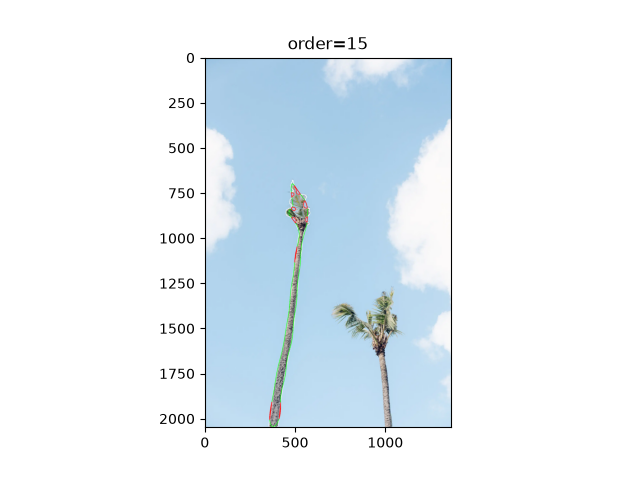

In [10]:
#  Add damage polygons to image

for damage_polygon in damage_polygons:
    cv2.polylines(img, 
                  pts=[damage_polygon.astype(np.int32)], 
                  isClosed=True, 
                  color=(255,0,0), 
                  thickness=2
    )   
fig, ax = plt.subplots()
ax.imshow(img)
ax.set_title(f'{order=}')
plt.show()

In [11]:
# Add damage polygons to database

# calculate WKT polygons

def wkt_to_ints(wkt_str):
    # Find all floating point or integer numbers in the WKT string
    return re.sub(r'-?\d+\.\d+', lambda m: str(round(float(m.group(0)))), wkt_str)

wkts = []
for poly in damage_polygons:
    # poly = poly.astype(int) 
    poly = np.squeeze(poly)         # get rid of unnecessary dimensions
    if (poly[-1] != poly[0]).all(): # ensure polygon is closed
        np.vstack([poly, poly[0]])
    wkt = dumps(Polygon(poly))
    wkt = wkt_to_ints(wkt)          # convert coords from float to int
    wkts.append(wkt) 
       
cursor.execute('DELETE from damage')   # TEMP: delete all records from damage table
conn.commit()

for wkt in wkts:   # add records to damage table
    cursor.execute('INSERT INTO damage (image_id, tree_id, damage_poly) VALUES (?, ?, GeomFromText(?, 0))', 
                    (image_id, tree_id, wkt))
conn.commit()

In [12]:
ic('FINISHED')

ic| 'FINISHED'


'FINISHED'